Sales Forecasting Project
First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Categ

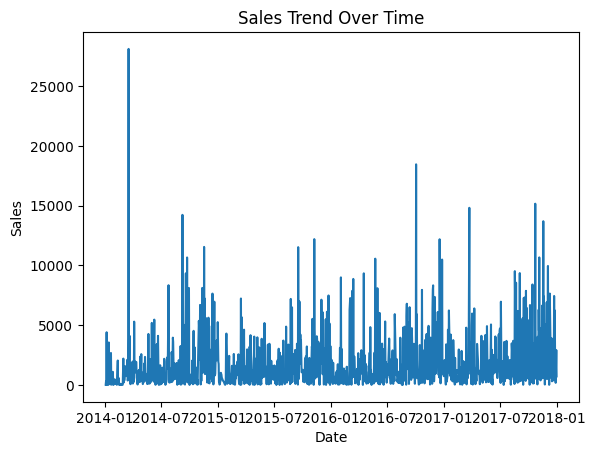


Model Error (MAE): 1756.6584944000608


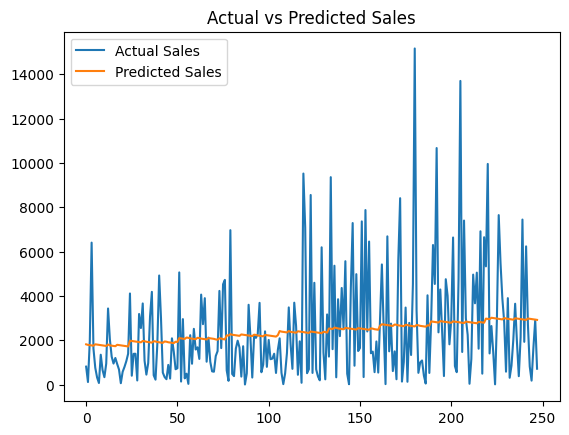


Future Sales Prediction:
         Date  Predicted Sales
0  2017-12-30      2917.094593
1  2017-12-31      2904.655569
2  2018-01-01      1614.878192
3  2018-01-02      1602.439168
4  2018-01-03      1590.000143
5  2018-01-04      1577.561119
6  2018-01-05      1565.122095
7  2018-01-06      1552.683071
8  2018-01-07      1540.244046
9  2018-01-08      1603.627229
10 2018-01-09      1591.188205
11 2018-01-10      1578.749181
12 2018-01-11      1566.310156
13 2018-01-12      1553.871132
14 2018-01-13      1541.432108
15 2018-01-14      1528.993083
16 2018-01-15      1592.376266
17 2018-01-16      1579.937242
18 2018-01-17      1567.498218
19 2018-01-18      1555.059193
20 2018-01-19      1542.620169
21 2018-01-20      1530.181145
22 2018-01-21      1517.742121
23 2018-01-22      1581.125303
24 2018-01-23      1568.686279
25 2018-01-24      1556.247255
26 2018-01-25      1543.808231
27 2018-01-26      1531.369206
28 2018-01-27      1518.930182
29 2018-01-28      1506.491158


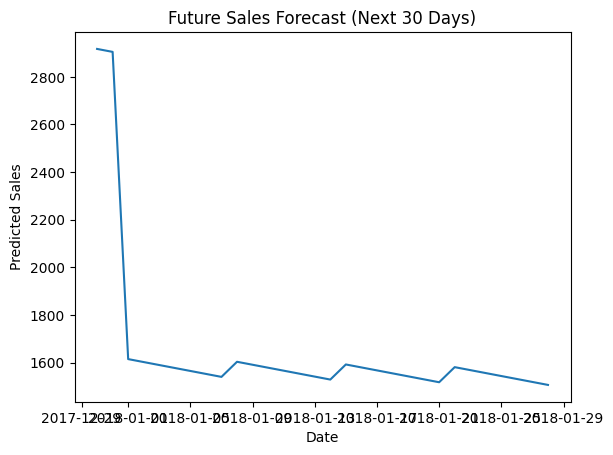

In [6]:
# ================================
# SALES FORECASTING FULL PROJECT
# ================================
print("Sales Forecasting Project")
# STEP 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# STEP 2: Load dataset
# Check if the file exists locally, otherwise prompt for upload
try:
    df = pd.read_csv("Superstore.csv", encoding='latin1')
except FileNotFoundError:
    print("Superstore.csv not found. Please upload the file.")
    from google.colab import files
    uploaded = files.upload()
    if "Superstore.csv" in uploaded:
        df = pd.read_csv("Superstore.csv", encoding='latin1')
        print("Superstore.csv uploaded successfully.")
    else:
        raise FileNotFoundError("Superstore.csv was not uploaded. Please try again.")
except UnicodeDecodeError:
    print("UnicodeDecodeError: Could not decode 'Superstore.csv' with 'latin1' encoding. Trying 'cp1252'.")
    try:
        df = pd.read_csv("Superstore.csv", encoding='cp1252')
        print("Superstore.csv loaded successfully with 'cp1252' encoding.")
    except Exception as e:
        raise ValueError(f"Failed to load 'Superstore.csv' with 'latin1' or 'cp1252' encoding: {e}")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# STEP 3: Data Cleaning
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date')
df = df.ffill() # Updated to use ffill() directly as suggested by FutureWarning

# STEP 4: Convert to daily sales (Time Series)
sales_data = df.groupby('Order Date')['Sales'].sum().reset_index()

# STEP 5: Feature Engineering
sales_data['year'] = sales_data['Order Date'].dt.year
sales_data['month'] = sales_data['Order Date'].dt.month
sales_data['day'] = sales_data['Order Date'].dt.day
sales_data['day_of_week'] = sales_data['Order Date'].dt.dayofweek

# STEP 6: Visualize sales trend
plt.figure()
plt.plot(sales_data['Order Date'], sales_data['Sales'])
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# STEP 7: Prepare data for model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = sales_data[['year', 'month', 'day', 'day_of_week']]
y = sales_data['Sales']

# IMPORTANT: No shuffle (time-series data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# STEP 8: Train model
model = LinearRegression()
model.fit(X_train, y_train)

# STEP 9: Predictions
predictions = model.predict(X_test)

# STEP 10: Evaluation
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print("\nModel Error (MAE):", mae)

# STEP 11: Plot Actual vs Predicted
plt.figure()
plt.plot(y_test.values, label="Actual Sales")
plt.plot(predictions, label="Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

# STEP 12: Future Forecast (Next 30 days)
future_dates = pd.date_range(start=sales_data['Order Date'].max(), periods=30)

future_df = pd.DataFrame({
    'year': future_dates.year,
    'month': future_dates.month,
    'day': future_dates.day,
    'day_of_week': future_dates.dayofweek
})

future_sales = model.predict(future_df)

# STEP 13: Show future predictions
future_output = pd.DataFrame({
    'Date': future_dates,
    'Predicted Sales': future_sales
})

print("\nFuture Sales Prediction:")
print(future_output)

# STEP 14: Plot future forecast
plt.figure()
plt.plot(future_output['Date'], future_output['Predicted Sales'])
plt.title("Future Sales Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.show()

# ================================
# DONE 🎉
# ================================